Creating model: ('PP-LCNet_x1_0_doc_ori', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\emili\.paddlex\official_models\PP-LCNet_x1_0_doc_ori`.
Creating model: ('UVDoc', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\emili\.paddlex\official_models\UVDoc`.
Creating model: ('PP-LCNet_x1_0_textline_ori', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\emili\.paddlex\official_models\PP-LCNet_x1_0_textline_ori`.
Creating model: ('PP-OCRv5_server_det', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\emili\.paddlex\official_models\PP-OCRv5_server_det`.
Creating model: ('eslav_PP-OCRv5_mobile_rec', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\emili\.paddl

РАСПОЗНАВАНИЕ ТЕКСТА (КЛАСТЕРИЗАЦИЯ OPTICS)

--- Распознавание (размер: 2000) ---
Найдено блоков: 8

--- Распознавание (размер: 2500) ---
Найдено блоков: 8

ВСЕ РАСПОЗНАННЫЕ БЛОКИ (в правильном порядке):
[ 0] xpcyx                                    y:    28 x:    15 cls:0 (score:0.606)
[ 1] (Фрамция)                                y:    39 x:    15 cls:0 (score:0.821)
[ 2] EнHO CITRAN                              y:     0 x:    15 cls:0 (score:0.774)
[ 3] боpaо Суперьор                           y:     9 x:    14 cls:0 (score:0.512)
[ 4] 0.75L                                    y:    40 x:    66 cls:0 (score:0.902)
[ 5] Cyxoe                                    y:    56 x:    29 cls:1 (score:0.868)
[ 6] -2791899                                 y:    80 x:     7 cls:1 (score:0.875)
[ 7] 2631                                     y:    59 x:   104 cls:1 (score:0.993)

ПОЛНЫЙ ТЕКСТ (в правильном порядке):
xpcyx (Фрамция) EнHO CITRAN боpaо Суперьор 0.75L Cyxoe -2791899 2631


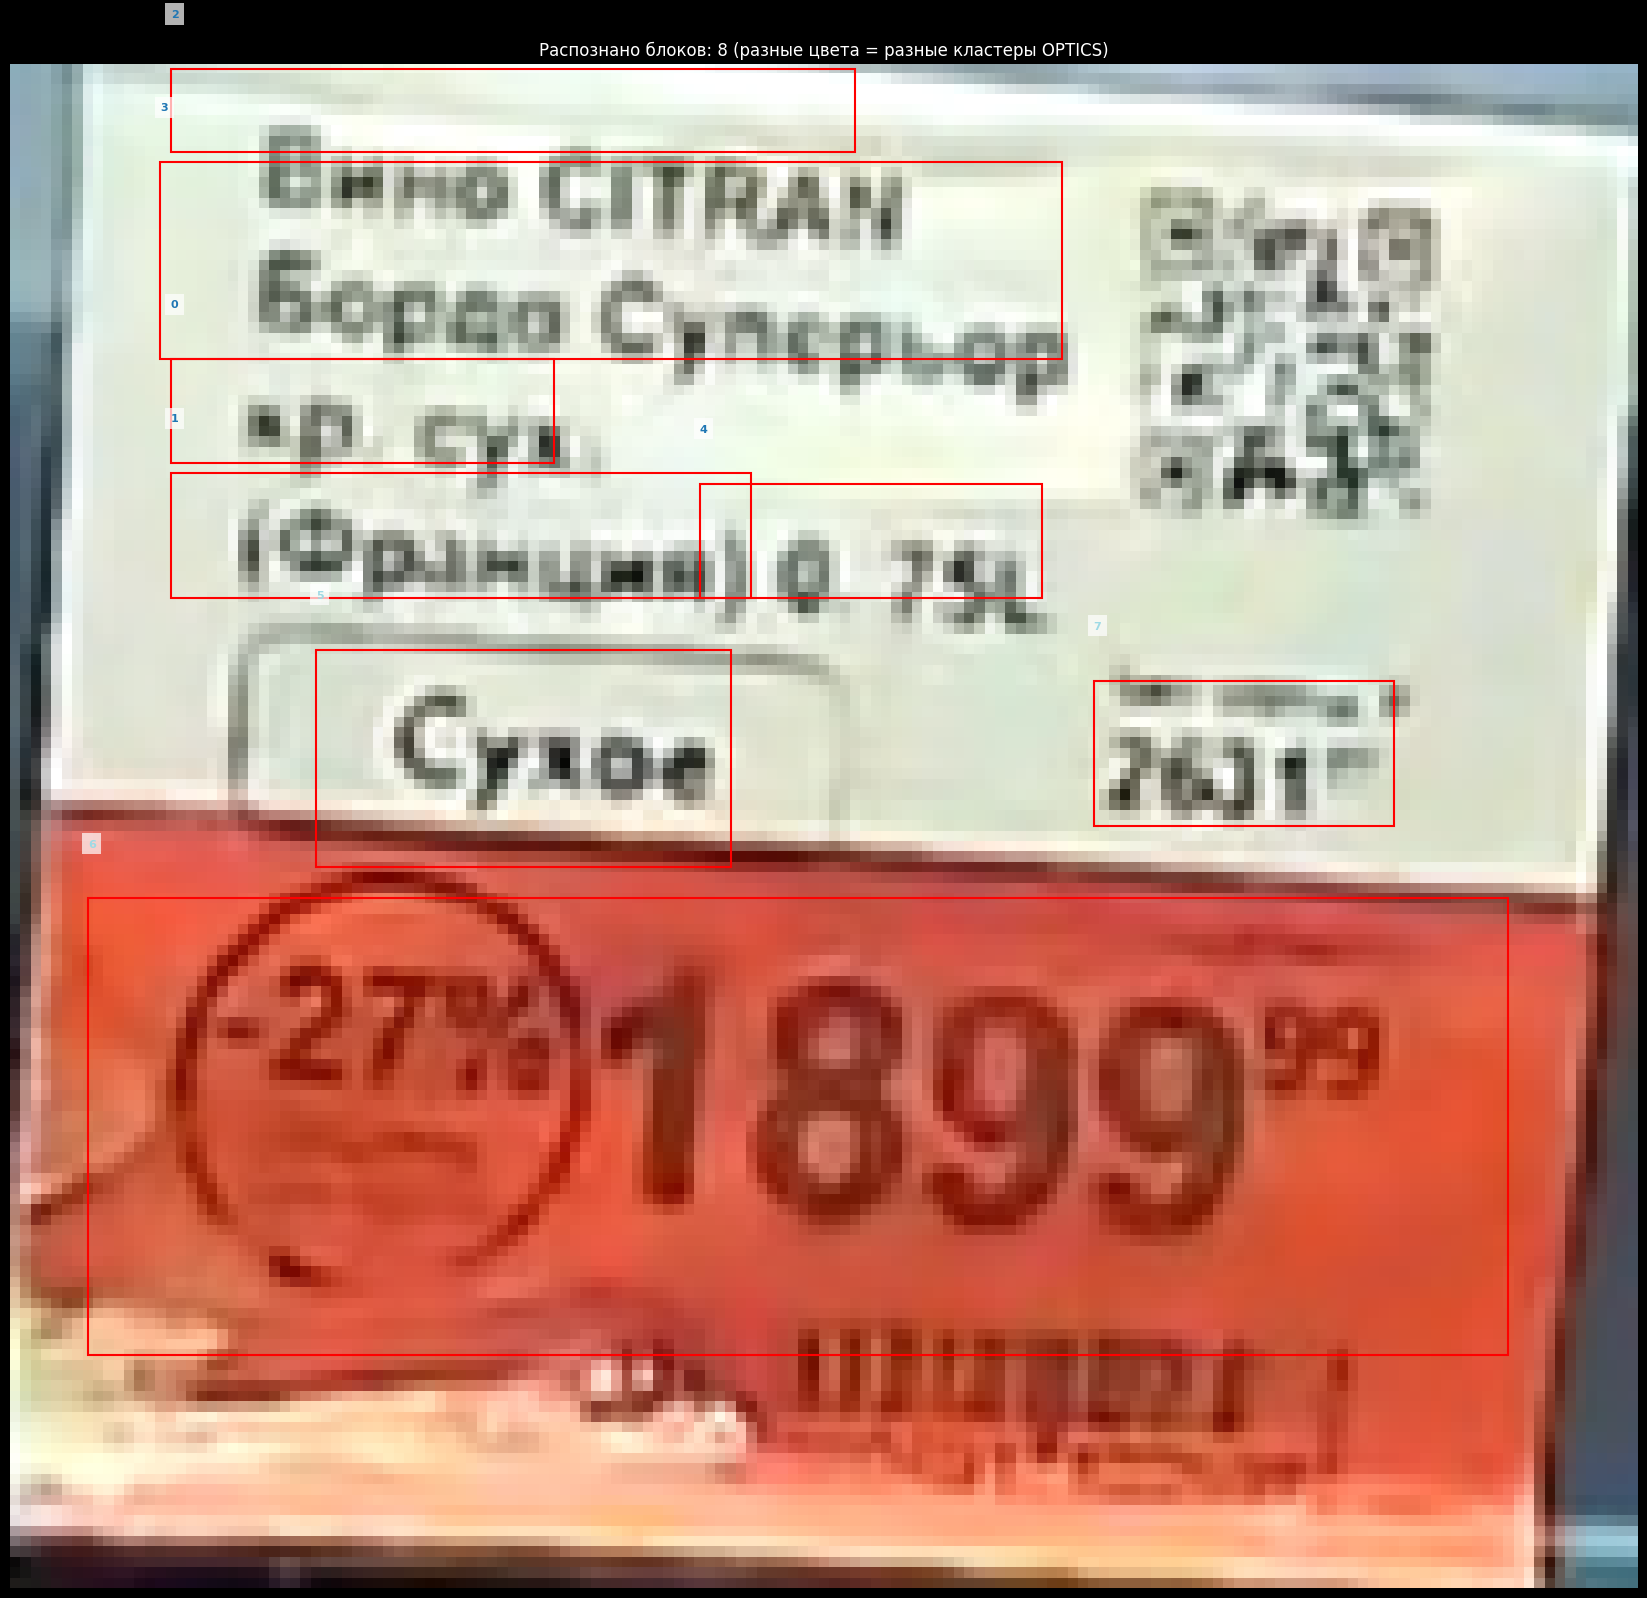


ТЕКСТ ПО СТРОКАМ (на основе кластеров):
Кластер 0: xpcyx (Фрамция) EнHO CITRAN боpaо Суперьор 0.75L
Кластер 1: Cyxoe -2791899 2631


In [74]:
from paddleocr import PaddleOCR
import cv2
import numpy as np
import re
from sklearn.cluster import OPTICS

# =========================================================
# OCR INIT
# =========================================================

ocr = PaddleOCR(
    lang='ru',
    use_textline_orientation=True,
    text_det_thresh=0.25,
    text_det_box_thresh=0.25,
    text_rec_score_thresh=0.2,
    device='cpu'
)


# =========================================================
# IMAGE PREPROCESSING
# =========================================================

def resize_by_long_edge(img, target_size=2000):
    """Изменяет размер, возвращает коэффициент масштаба"""
    h, w = img.shape[:2]

    if max(h, w) <= target_size:
        return img, 1.0, 1.0

    if h > w:
        scale = target_size / h
        new_h = target_size
        new_w = int(w * scale)
    else:
        scale = target_size / w
        new_w = target_size
        new_h = int(h * scale)

    resized = cv2.resize(img, (new_w, new_h), interpolation=cv2.INTER_CUBIC)
    return resized, scale, scale


def preprocess_image(image_path, target_size=2000):
    """Предобработка с сохранением коэффициентов масштаба"""
    img = cv2.imread(image_path)

    if img is None:
        raise ValueError(f"Не удалось загрузить изображение: {image_path}")

    # Приводим к 3 каналам
    if len(img.shape) == 2:
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    if img.shape[2] == 4:
        img = cv2.cvtColor(img, cv2.COLOR_BGRA2BGR)

    # Изменяем размер
    resized, scale_x, scale_y = resize_by_long_edge(img, target_size)

    return resized, scale_x, scale_y


# =========================================================
# OCR С КОРРЕКТНЫМИ КООРДИНАТАМИ
# =========================================================

def extract_all_text(image_path, target_size=2000):
    """Извлекает текст с корректными координатами"""
    processed, scale_x, scale_y = preprocess_image(image_path, target_size)

    result = ocr.predict(processed)

    if not result or len(result) == 0:
        return []

    ocr_result = result[0]

    rec_texts = ocr_result.get('rec_texts', [])
    rec_scores = ocr_result.get('rec_scores', [])
    rec_polys = ocr_result.get('rec_polys', [])

    all_boxes = []

    for text, score, poly in zip(rec_texts, rec_scores, rec_polys):
        if score < 0.25:
            continue

        text = str(text).strip()
        if len(text) == 0:
            continue

        # Масштабируем координаты обратно
        scaled_poly = []
        for p in poly:
            scaled_poly.append([p[0] / scale_x, p[1] / scale_y])

        xs = [p[0] for p in scaled_poly]
        ys = [p[1] for p in scaled_poly]

        all_boxes.append({
            'text': text,
            'score': score,
            'x': min(xs),
            'y': min(ys),
            'w': max(xs) - min(xs),
            'h': max(ys) - min(ys),
            'center_x': np.mean(xs),
            'center_y': np.mean(ys),
            'y_top': min(ys),
            'y_bottom': max(ys)
        })

    return all_boxes


# =========================================================
# КЛАСТЕРИЗАЦИЯ OPTICS И СОРТИРОВКА
# =========================================================

def cluster_and_sort_boxes(boxes, min_cluster_size=2, xi=0.05):
    """
    Кластеризация блоков с помощью OPTICS по вертикали,
    затем сортировка внутри кластеров по горизонтали
    """
    if not boxes:
        return [], []

    # Извлекаем Y-координаты центров блоков
    y_coords = np.array([[b['center_y']] for b in boxes])

    # Применяем OPTICS для кластеризации по вертикали
    clustering = OPTICS(min_samples=min_cluster_size, xi=xi, min_cluster_size=min_cluster_size)
    labels = clustering.fit_predict(y_coords)

    # Преобразуем в список Python
    labels = labels.tolist()

    # Группируем блоки по кластерам
    clusters = {}
    for i, (box, label) in enumerate(zip(boxes, labels)):
        if label not in clusters:
            clusters[label] = []
        clusters[label].append(box)

    # Сортируем кластеры по среднему Y
    sorted_clusters = []
    for label in sorted(clusters.keys()):
        cluster_boxes = clusters[label]
        # Сортируем блоки внутри кластера по X (слева направо)
        cluster_boxes.sort(key=lambda b: b['center_x'])
        # Вычисляем средний Y для кластера
        avg_y = np.mean([b['center_y'] for b in cluster_boxes])
        sorted_clusters.append((avg_y, cluster_boxes, label))

    # Сортируем кластеры по Y
    sorted_clusters.sort(key=lambda x: x[0])

    # Разворачиваем в плоский список
    result = []
    result_labels = []
    for _, cluster_boxes, label in sorted_clusters:
        for box in cluster_boxes:
            result.append(box)
            result_labels.append(label)

    return result, result_labels


# =========================================================
# ВИЗУАЛИЗАЦИЯ
# =========================================================

def visualize_boxes(image_path, boxes, labels=None):
    """Визуализация блоков с номерами и цветами кластеров"""
    img = cv2.imread(image_path)
    if img is None:
        return

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    import matplotlib.pyplot as plt
    from matplotlib.patches import Rectangle
    import matplotlib.cm as cm

    plt.figure(figsize=(20, 16))
    plt.imshow(img)

    # Генерация цветов для кластеров
    if labels is not None and len(labels) > 0:
        unique_labels = set(labels)
        colors = cm.tab20(np.linspace(0, 1, len(unique_labels)))
        label_to_color = {label: colors[i] for i, label in enumerate(unique_labels)}
    else:
        label_to_color = {}

    for i, box in enumerate(boxes):
        rect = Rectangle(
            (box['x'], box['y']),
            box['w'], box['h'],
            linewidth=1.5,
            edgecolor='red',
            facecolor='none'
        )
        plt.gca().add_patch(rect)

        # Определяем цвет текста
        if labels is not None and i < len(labels) and labels[i] != -1:
            color = label_to_color.get(labels[i], 'blue')
        else:
            color = 'blue'

        plt.text(
            box['x'], box['y'] - 5,
            f"{i}",
            fontsize=8,
            color=color,
            fontweight='bold',
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none')
        )

    plt.axis('off')
    plt.title(f"Распознано блоков: {len(boxes)} (разные цвета = разные кластеры OPTICS)")
    plt.tight_layout()
    plt.show()


# =========================================================
# ОСНОВНАЯ ФУНКЦИЯ
# =========================================================

def parse_price_tag(image_path, target_size=2000):
    """Основная функция для распознавания ценника"""

    print(f"\n--- Распознавание (размер: {target_size}) ---")

    # Извлекаем блоки
    boxes = extract_all_text(image_path, target_size)

    if not boxes:
        print("Ничего не найдено")
        return None, [], []

    print(f"Найдено блоков: {len(boxes)}")

    # Кластеризация и сортировка
    sorted_boxes, labels = cluster_and_sort_boxes(boxes, min_cluster_size=2, xi=0.05)

    return sorted_boxes, boxes, labels


# =========================================================
# ТЕСТИРОВАНИЕ
# =========================================================

if __name__ == "__main__":

    image_path = "../test_img/img_6.png"

    print("=" * 80)
    print("РАСПОЗНАВАНИЕ ТЕКСТА (КЛАСТЕРИЗАЦИЯ OPTICS)")
    print("=" * 80)

    # Пробуем разные размеры
    best_boxes = []
    best_labels = None
    best_count = 0

    for target_size in [2000, 2500]:
        sorted_boxes, raw_boxes, labels = parse_price_tag(image_path, target_size)

        if sorted_boxes and len(sorted_boxes) > best_count:
            best_count = len(sorted_boxes)
            best_boxes = sorted_boxes
            best_labels = labels

    if best_boxes:
        print("\n" + "=" * 80)
        print("ВСЕ РАСПОЗНАННЫЕ БЛОКИ (в правильном порядке):")
        print("=" * 80)

        for i, box in enumerate(best_boxes):
            label_info = ""
            if best_labels is not None and i < len(best_labels):
                label_info = f"cls:{best_labels[i]}"
            print(f"[{i:2}] {box['text']:40} "
                  f"y:{box['y']:6.0f} x:{box['x']:6.0f} "
                  f"{label_info} (score:{box['score']:.3f})")

        # Полный текст
        full_text = ' '.join([b['text'] for b in best_boxes])

        print("\n" + "=" * 80)
        print("ПОЛНЫЙ ТЕКСТ (в правильном порядке):")
        print("=" * 80)
        print(full_text)

        # Визуализация
        visualize_boxes(image_path, best_boxes, best_labels)

        # Группировка по строкам для наглядности
        print("\n" + "=" * 80)
        print("ТЕКСТ ПО СТРОКАМ (на основе кластеров):")
        print("=" * 80)

        if best_labels is not None and len(best_labels) > 0:
            # Группируем по кластерам
            clusters_text = {}
            for i, (box, label) in enumerate(zip(best_boxes, best_labels)):
                if label not in clusters_text:
                    clusters_text[label] = []
                clusters_text[label].append(box['text'])

            for label in sorted(clusters_text.keys()):
                row_text = ' '.join(clusters_text[label])
                print(f"Кластер {label}: {row_text}")
        else:
            # fallback
            rows = []
            current_row = [best_boxes[0]]
            for box in best_boxes[1:]:
                avg_y = np.mean([b['center_y'] for b in current_row])
                if abs(box['center_y'] - avg_y) <= 20:
                    current_row.append(box)
                else:
                    row_text = ' '.join([b['text'] for b in current_row])
                    rows.append(row_text)
                    current_row = [box]
            if current_row:
                row_text = ' '.join([b['text'] for b in current_row])
                rows.append(row_text)
            for i, row in enumerate(rows):
                print(f"Строка {i+1}: {row}")

    else:
        print("Не удалось распознать ценник")

Creating model: ('PP-LCNet_x1_0_doc_ori', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\emili\.paddlex\official_models\PP-LCNet_x1_0_doc_ori`.
Creating model: ('UVDoc', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\emili\.paddlex\official_models\UVDoc`.
Creating model: ('PP-LCNet_x1_0_textline_ori', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\emili\.paddlex\official_models\PP-LCNet_x1_0_textline_ori`.
Creating model: ('PP-OCRv5_server_det', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\emili\.paddlex\official_models\PP-OCRv5_server_det`.
Creating model: ('eslav_PP-OCRv5_mobile_rec', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\emili\.paddl

РАСПОЗНАВАНИЕ ТЕКСТА (OPTICS + КОРРЕКЦИЯ ПОРЯДКА)

--- Распознавание (размер: 2000) ---
Найдено блоков: 11

--- Распознавание (размер: 2500) ---
Найдено блоков: 11

ВСЕ РАСПОЗНАННЫЕ БЛОКИ (в правильном порядке):
[ 0] шк:                                           y:   219 x:     0 (cls:3)
[ 1] 160404_633570                                 y:   231 x:     0 (cls:3)
[ 2] 26.01.2026 15:39                              y:   246 x:   134 (cls:3)
[ 3] 05                                            y:   248 x:     0 (cls:3)
[ 4] 789                                           y:   151 x:   285 (cls:2)
[ 5] без карты, ₽/кг: 831, 57                      y:   193 x:     0 (cls:2)
[ 6] Печенье Орешки со                             y:     0 x:     1 (cls:0)
[ 7] сгущенкой вес (СП) (Россия)                   y:    26 x:     0 (cls:0)
[ 8] С картой за                                   y:   117 x:   412 (cls:1)
[ 9] 99                                            y:   151 x:   528 (cls:-1)
[10] кг,         

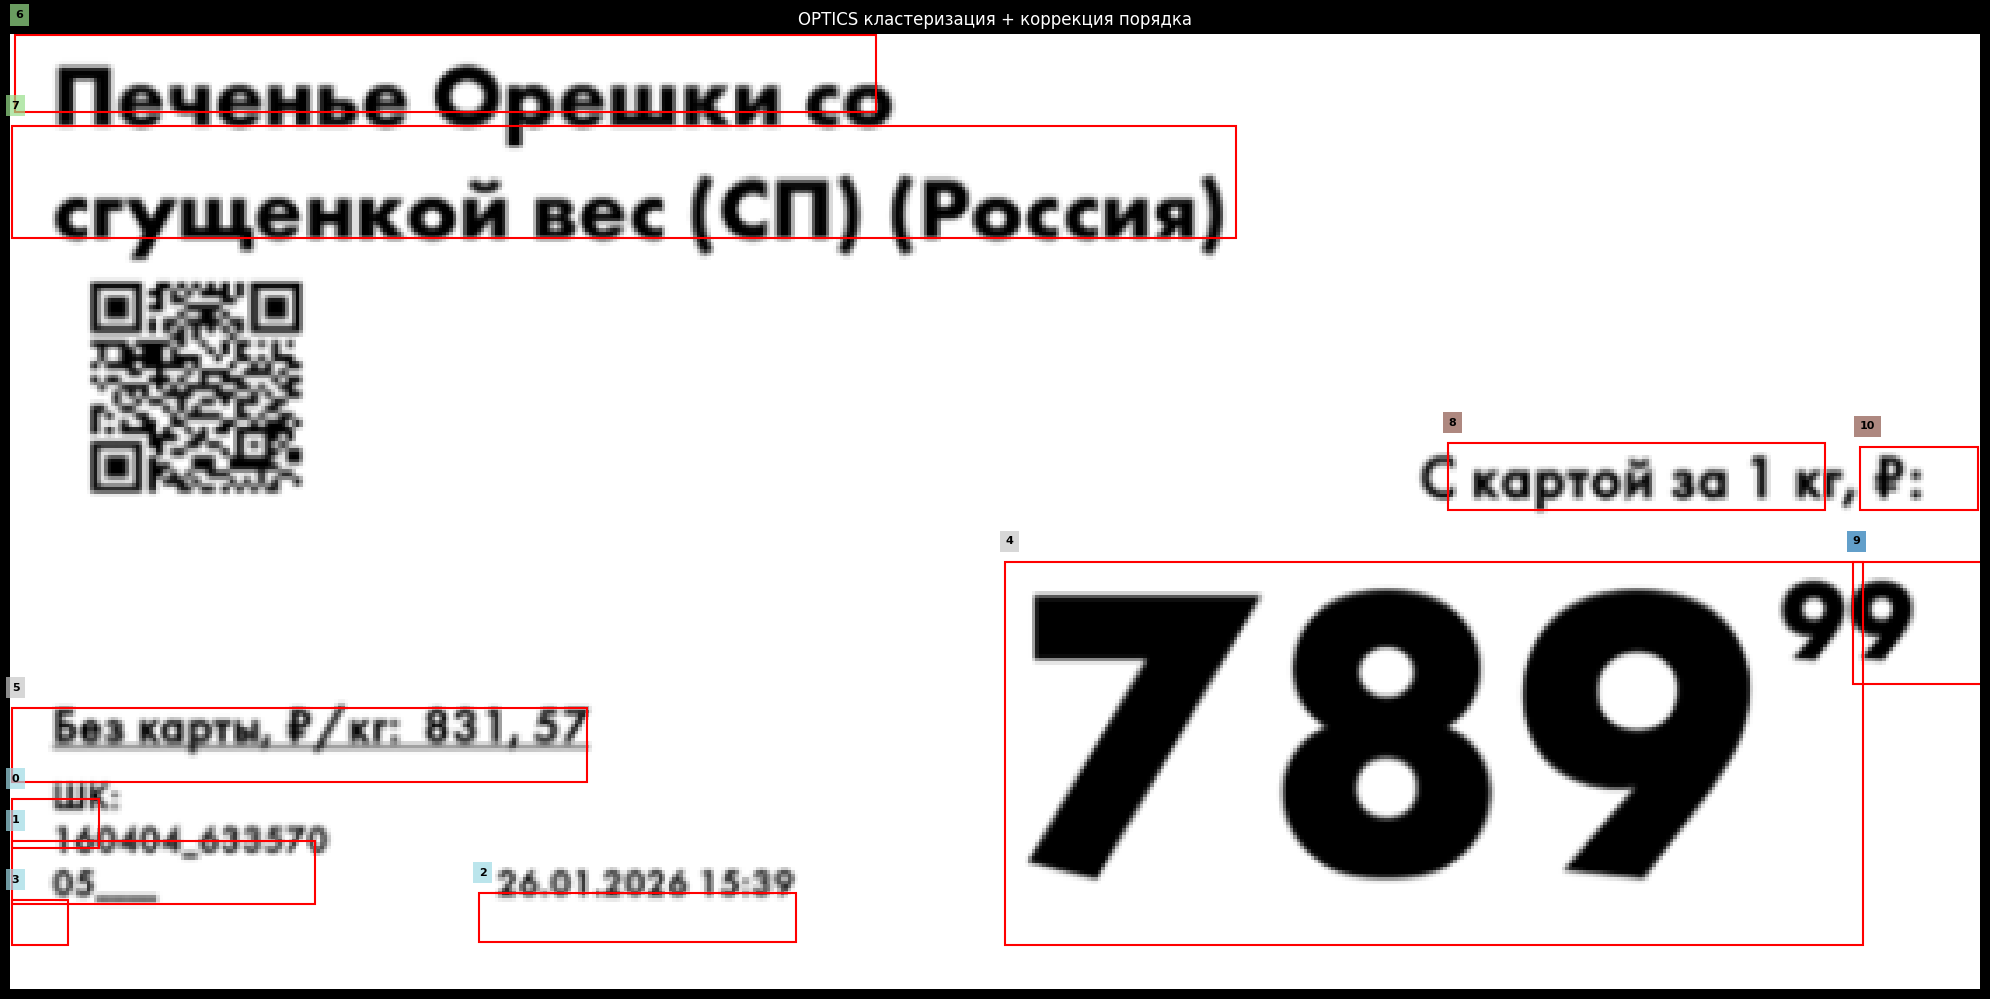


ТЕКСТ ПО КЛАСТЕРАМ (СТРОКАМ):
Кластер -1: 99
Кластер 0: Печенье Орешки со сгущенкой вес (СП) (Россия)
Кластер 1: С картой за кг,
Кластер 2: 789 без карты, ₽/кг: 831, 57
Кластер 3: шк: 160404_633570 26.01.2026 15:39 05


In [55]:
from paddleocr import PaddleOCR
import cv2
import numpy as np
import re
from sklearn.cluster import OPTICS

# =========================================================
# OCR INIT
# =========================================================

ocr = PaddleOCR(
    lang='ru',
    use_textline_orientation=True,
    text_det_thresh=0.25,
    text_det_box_thresh=0.25,
    text_rec_score_thresh=0.2,
    device='cpu'
)


# =========================================================
# IMAGE PREPROCESSING
# =========================================================

def resize_by_long_edge(img, target_size=2000):
    """Изменяет размер, возвращает коэффициент масштаба"""
    h, w = img.shape[:2]

    if max(h, w) <= target_size:
        return img, 1.0, 1.0

    if h > w:
        scale = target_size / h
        new_h = target_size
        new_w = int(w * scale)
    else:
        scale = target_size / w
        new_w = target_size
        new_h = int(h * scale)

    resized = cv2.resize(img, (new_w, new_h), interpolation=cv2.INTER_CUBIC)
    return resized, scale, scale


def preprocess_image(image_path, target_size=2000):
    """Предобработка с сохранением коэффициентов масштаба"""
    img = cv2.imread(image_path)

    if img is None:
        raise ValueError(f"Не удалось загрузить изображение: {image_path}")

    if len(img.shape) == 2:
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    if img.shape[2] == 4:
        img = cv2.cvtColor(img, cv2.COLOR_BGRA2BGR)

    resized, scale_x, scale_y = resize_by_long_edge(img, target_size)

    return resized, scale_x, scale_y


# =========================================================
# OCR С КОРРЕКТНЫМИ КООРДИНАТАМИ
# =========================================================

def extract_all_text(image_path, target_size=2000):
    """Извлекает текст с корректными координатами"""
    processed, scale_x, scale_y = preprocess_image(image_path, target_size)

    result = ocr.predict(processed)

    if not result or len(result) == 0:
        return []

    ocr_result = result[0]

    rec_texts = ocr_result.get('rec_texts', [])
    rec_scores = ocr_result.get('rec_scores', [])
    rec_polys = ocr_result.get('rec_polys', [])

    all_boxes = []

    for text, score, poly in zip(rec_texts, rec_scores, rec_polys):
        if score < 0.25:
            continue

        text = str(text).strip()
        if len(text) == 0:
            continue

        scaled_poly = []
        for p in poly:
            scaled_poly.append([p[0] / scale_x, p[1] / scale_y])

        xs = [p[0] for p in scaled_poly]
        ys = [p[1] for p in scaled_poly]

        all_boxes.append({
            'text': text,
            'score': score,
            'x': min(xs),
            'y': min(ys),
            'w': max(xs) - min(xs),
            'h': max(ys) - min(ys),
            'center_x': np.mean(xs),
            'center_y': np.mean(ys),
            'y_top': min(ys),
            'y_bottom': max(ys)
        })

    return all_boxes


# =========================================================
# КЛАСТЕРИЗАЦИЯ OPTICS + КОРРЕКЦИЯ ПОРЯДКА
# =========================================================

def cluster_and_sort(boxes, min_cluster_size=2, xi=0.05):
    """
    1. Кластеризация OPTICS по вертикали
    2. Внутри каждого кластера сортировка по X
    3. Кластеры сортируются по среднему Y
    4. КОРРЕКЦИЯ: если блок правее и ниже, он не может идти раньше
    """
    if not boxes:
        return [], []

    # Извлекаем Y-координаты центров
    y_coords = np.array([[b['center_y']] for b in boxes])

    # OPTICS кластеризация
    clustering = OPTICS(min_samples=min_cluster_size, xi=xi, min_cluster_size=min_cluster_size)
    labels = clustering.fit_predict(y_coords)
    labels = labels.tolist()

    # Группируем по кластерам
    clusters = {}
    for i, (box, label) in enumerate(zip(boxes, labels)):
        if label not in clusters:
            clusters[label] = []
        clusters[label].append(box)

    # Внутри каждого кластера: сортируем по X (слева направо)
    for label in clusters:
        clusters[label].sort(key=lambda b: b['x'])

    # Вычисляем средний Y для каждого кластера
    cluster_info = []
    for label, cluster_boxes in clusters.items():
        avg_y = np.mean([b['center_y'] for b in cluster_boxes])
        cluster_info.append((label, avg_y))

    # Сортируем кластеры по среднему Y (сверху вниз)
    cluster_info.sort(key=lambda x: x[1])

    # Формируем предварительный результат
    result_boxes = []
    result_labels = []
    for label, _ in cluster_info:
        for box in clusters[label]:
            result_boxes.append(box)
            result_labels.append(label)

    # =========================================================
    # КОРРЕКЦИЯ ПОРЯДКА: если блок правее и ниже, он не может идти раньше
    # =========================================================
    corrected = False
    for i in range(len(result_boxes) - 1):
        for j in range(i + 1, len(result_boxes)):
            current = result_boxes[i]
            next_box = result_boxes[j]

            # Если текущий блок правее И ниже следующего - меняем местами
            if (current['x'] > next_box['x'] or
                current['y'] > next_box['y']):
                # Меняем местами
                result_boxes[i], result_boxes[j] = result_boxes[j], result_boxes[i]
                result_labels[i], result_labels[j] = result_labels[j], result_labels[i]
                corrected = True

    return result_boxes, result_labels


# =========================================================
# ВИЗУАЛИЗАЦИЯ
# =========================================================

def visualize_clusters(image_path, boxes, labels):
    """Визуализация кластеров разными цветами"""
    img = cv2.imread(image_path)
    if img is None:
        return

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    import matplotlib.pyplot as plt
    from matplotlib.patches import Rectangle
    import matplotlib.cm as cm

    plt.figure(figsize=(20, 16))
    plt.imshow(img)

    unique_labels = sorted(set(labels))
    colors = cm.tab20(np.linspace(0, 1, len(unique_labels)))
    label_to_color = {label: colors[i] for i, label in enumerate(unique_labels)}

    for i, (box, label) in enumerate(zip(boxes, labels)):
        rect = Rectangle(
            (box['x'], box['y']),
            box['w'], box['h'],
            linewidth=1.5,
            edgecolor='red',
            facecolor='none'
        )
        plt.gca().add_patch(rect)

        color = label_to_color.get(label, 'blue')
        plt.text(
            box['x'], box['y'] - 5,
            f"{i}",
            fontsize=8,
            color='black',
            fontweight='bold',
            bbox=dict(facecolor=color, alpha=0.7, edgecolor='none')
        )

    plt.axis('off')
    plt.title(f"OPTICS кластеризация + коррекция порядка")
    plt.tight_layout()
    plt.show()


# =========================================================
# ОСНОВНАЯ ФУНКЦИЯ
# =========================================================

def parse_price_tag(image_path, target_size=2000):
    """Основная функция для распознавания ценника"""

    print(f"\n--- Распознавание (размер: {target_size}) ---")

    boxes = extract_all_text(image_path, target_size)

    if not boxes:
        print("Ничего не найдено")
        return None, None

    print(f"Найдено блоков: {len(boxes)}")

    # Кластеризация и сортировка с коррекцией
    sorted_boxes, labels = cluster_and_sort(boxes, min_cluster_size=2, xi=0.05)

    return sorted_boxes, labels


# =========================================================
# ТЕСТИРОВАНИЕ
# =========================================================

if __name__ == "__main__":

    image_path = "../test_img/img_1.png"  # печенье

    print("=" * 80)
    print("РАСПОЗНАВАНИЕ ТЕКСТА (OPTICS + КОРРЕКЦИЯ ПОРЯДКА)")
    print("=" * 80)

    best_boxes = []
    best_labels = None
    best_count = 0

    for target_size in [2000, 2500]:
        sorted_boxes, labels = parse_price_tag(image_path, target_size)

        if sorted_boxes and len(sorted_boxes) > best_count:
            best_count = len(sorted_boxes)
            best_boxes = sorted_boxes
            best_labels = labels

    if best_boxes:
        print("\n" + "=" * 80)
        print("ВСЕ РАСПОЗНАННЫЕ БЛОКИ (в правильном порядке):")
        print("=" * 80)

        for i, (box, label) in enumerate(zip(best_boxes, best_labels)):
            print(f"[{i:2}] {box['text']:45} "
                  f"y:{box['y']:6.0f} x:{box['x']:6.0f} "
                  f"(cls:{label})")

        # Полный текст
        full_text = ' '.join([b['text'] for b in best_boxes])

        print("\n" + "=" * 80)
        print("ПОЛНЫЙ ТЕКСТ:")
        print("=" * 80)
        print(full_text)

        # Визуализация
        if best_labels:
            visualize_clusters(image_path, best_boxes, best_labels)

        # Текст по строкам
        print("\n" + "=" * 80)
        print("ТЕКСТ ПО КЛАСТЕРАМ (СТРОКАМ):")
        print("=" * 80)

        if best_labels:
            clusters_text = {}
            for box, label in zip(best_boxes, best_labels):
                if label not in clusters_text:
                    clusters_text[label] = []
                clusters_text[label].append(box['text'])

            for label in sorted(clusters_text.keys()):
                print(f"Кластер {label}: {' '.join(clusters_text[label])}")
    else:
        print("Не удалось распознать ценник")

In [72]:
import pandas as pd
import re
import numpy as np

def parse_price_tag_final(image_path, target_size=2000):
    """
    Полный парсинг ценника из данных кластеризации
    """
    # Вызываем функцию кластеризации
    result = parse_price_tag(image_path, target_size)

    # Извлекаем данные в зависимости от формата
    if isinstance(result, tuple):
        if len(result) >= 2:
            sorted_boxes = result[0]
            labels = result[1] if len(result) > 1 else None
        else:
            print("Ошибка: недостаточно данных")
            return pd.DataFrame()
    else:
        print(f"Ошибка: неожиданный формат {type(result)}")
        return pd.DataFrame()

    if not sorted_boxes:
        print("Ошибка: нет распознанных блоков")
        return pd.DataFrame()

    # Проверяем тип элементов и преобразуем если нужно
    if isinstance(sorted_boxes[0], dict):
        # Уже словари с координатами
        boxes_dict = sorted_boxes
        for box in boxes_dict:
            box['font_size'] = box.get('h', box.get('height', 20))
    elif isinstance(sorted_boxes[0], str):
        # Это список строк, создаем искусственные координаты
        boxes_dict = []
        y_offset = 0
        for i, text in enumerate(sorted_boxes):
            boxes_dict.append({
                'text': text,
                'x': 0,
                'y': y_offset,
                'center_x': 0,
                'center_y': y_offset,
                'font_size': 20,
                'h': 20
            })
            y_offset += 30
    else:
        print(f"Неизвестный тип: {type(sorted_boxes[0])}")
        return pd.DataFrame()

    # =========================================================
    # 1. ГРУППИРУЕМ ПО КЛАСТЕРАМ (если есть метки)
    # =========================================================
    if labels and len(labels) == len(boxes_dict):
        clusters_boxes = {}
        for box, label in zip(boxes_dict, labels):
            if label not in clusters_boxes:
                clusters_boxes[label] = []
            clusters_boxes[label].append(box)

        # Сортируем блоки в каждом кластере по X
        for label in clusters_boxes:
            clusters_boxes[label].sort(key=lambda b: b.get('x', 0))

        # Вычисляем средний Y для каждого кластера
        cluster_avg_y = {}
        for label, cluster_boxes in clusters_boxes.items():
            avg_y = np.mean([b.get('center_y', b.get('y', 0)) for b in cluster_boxes])
            cluster_avg_y[label] = avg_y

        sorted_clusters = sorted(cluster_avg_y.items(), key=lambda x: x[1])
    else:
        # Если нет меток, считаем все одним кластером
        sorted_clusters = [(0, boxes_dict)]
        clusters_boxes = {0: boxes_dict}

    # =========================================================
    # 2. НАЗВАНИЕ ТОВАРА (из первого кластера)
    # =========================================================
    product_name = None
    if sorted_clusters:
        first_cluster_label = sorted_clusters[0][0]
        first_cluster_boxes = clusters_boxes[first_cluster_label]

        name_parts = []
        skip_words = ['шк:', 'картой', 'без карты', 'кг,', '₽/кг', 'с картой', 'за']

        for box in first_cluster_boxes:
            text = box.get('text', '')
            is_skip = False
            for sw in skip_words:
                if sw in text.lower():
                    is_skip = True
                    break
            if not is_skip and len(text) > 1 and not text.isdigit():
                name_parts.append(text)

        if name_parts:
            product_name = ' '.join(name_parts)

    # =========================================================
    # 3. ЦЕНЫ (по размеру шрифта)
    # =========================================================
    numbers = []
    for box in boxes_dict:
        text = box.get('text', '')
        font_size = box.get('font_size', box.get('h', 20))

        # Числа с копейками
        matches = re.findall(r'(\d+)[,.](\d{2})', text)
        for rub, kop in matches:
            numbers.append({'value': float(f"{rub}.{kop}"), 'font_size': font_size})

        # Целые числа
        matches = re.findall(r'\b(\d{2,4})\b', text)
        for num in matches:
            val = int(num)
            if 10 < val < 1000:
                numbers.append({'value': float(val), 'font_size': font_size})

    if numbers:
        numbers.sort(key=lambda x: x['font_size'], reverse=True)
        unique = []
        seen = set()
        for n in numbers:
            if n['value'] not in seen:
                seen.add(n['value'])
                unique.append(n)

        price_default = unique[0]['value'] if len(unique) >= 1 else None
        price_card = unique[1]['value'] if len(unique) >= 2 else None
        price_discount = unique[2]['value'] if len(unique) >= 3 else None
    else:
        price_default = price_card = price_discount = None

    # =========================================================
    # 4. ШТРИХКОД
    # =========================================================
    barcode = None
    for box in boxes_dict:
        text = box.get('text', '')
        match = re.search(r'(\d{13})', text)
        if match:
            barcode = match.group(1)
            break
        match = re.search(r'(\d{6,7})[-_](\d{6,7})', text)
        if match:
            barcode = match.group(1) + match.group(2)
            break

    # =========================================================
    # 5. ДАТА И ВРЕМЯ
    # =========================================================
    print_datetime = None
    for box in boxes_dict:
        text = box.get('text', '')
        match = re.search(r'(\d{2})[./](\d{2})[./](\d{4})\s+(\d{2}):(\d{2})', text)
        if match:
            print_datetime = f"{match.group(1)}.{match.group(2)}.{match.group(3)} {match.group(4)}:{match.group(5)}"
            break

    # =========================================================
    # 6. АРТИКУЛ
    # =========================================================
    id_sku = None
    for box in boxes_dict:
        text = box.get('text', '')
        match = re.search(r'\b(\d{6,10})\b', text)
        if match and match.group(1) != barcode:
            id_sku = match.group(1)
            break

    # =========================================================
    # 7. СКИДКА
    # =========================================================
    discount_amount = None
    for box in boxes_dict:
        text = box.get('text', '')
        match = re.search(r'(\d+)[%％]', text)
        if match:
            discount_amount = int(match.group(1))
            break
        match = re.search(r'-(\d+)\s*%', text)
        if match:
            discount_amount = int(match.group(1))
            break

    # =========================================================
    # 8. ДОПОЛНИТЕЛЬНАЯ ИНФОРМАЦИЯ
    # =========================================================
    additional = []
    for box in boxes_dict:
        text_lower = box.get('text', '').lower()
        if 'вес' in text_lower or 'г.' in text_lower or 'россия' in text_lower:
            additional.append(box.get('text', ''))
    additional_info = ' | '.join(additional) if additional else None

    # =========================================================
    # 9. КОД ЗОНЫ ВЫКЛАДКИ
    # =========================================================
    code = None
    for box in boxes_dict:
        text = box.get('text', '')
        match = re.search(r'\b(\d{4,6})\b', text)
        if match:
            c = match.group(1)
            if c != barcode and c != id_sku:
                code = c
                break

    # =========================================================
    # 10. ТИП ВЫКЛАДКИ
    # =========================================================
    special_symbols = None
    for box in boxes_dict:
        text_lower = box.get('text', '').lower()
        if 'акция' in text_lower:
            special_symbols = 'акция'
            break
        if 'новинка' in text_lower or 'new' in text_lower:
            special_symbols = 'новинка'
            break

    # Собираем результат
    data = {
        'product_name': product_name,
        'price_default': price_default,
        'price_card': price_card,
        'price_discount': price_discount,
        'barcode': barcode,
        'discount_amount': discount_amount,
        'id_sku': id_sku,
        'print_datetime': print_datetime,
        'code': code,
        'additional_info': additional_info,
        'color': 'white',
        'special_symbols': special_symbols
    }

    return pd.DataFrame([data])


# =========================================================
# ТЕСТ
# =========================================================

image_path = "../test_img/img_1.png"

print("=" * 80)
print("ПАРСИНГ ЦЕННИКА")
print("=" * 80)

df = parse_price_tag_final(image_path, target_size=2000)

if not df.empty:
    print("\n" + "=" * 80)
    print("РЕЗУЛЬТАТЫ:")
    print("=" * 80)

    fields = [
        ('product_name', 'Наименование товара'),
        ('price_default', 'Цена без карты'),
        ('price_card', 'Цена по карте'),
        ('price_discount', 'Цена по акции'),
        ('discount_amount', 'Размер скидки'),
        ('barcode', 'Штрихкод'),
        ('id_sku', 'Артикул'),
        ('print_datetime', 'Дата и время печати'),
        ('code', 'Код зоны выкладки'),
        ('additional_info', 'Дополнительная информация'),
        ('color', 'Цвет ценника'),
        ('special_symbols', 'Тип выкладки')
    ]

    for key, label in fields:
        value = df.iloc[0].get(key)
        if value and str(value) != 'None':
            print(f"{label:25}: {value}")
        else:
            print(f"{label:25}: [не найден]")
else:
    print("Не удалось распознать ценник")

ПАРСИНГ ЦЕННИКА

--- Распознавание (размер: 2000) ---
Найдено блоков: 11

[DEBUG] Числа по размеру шрифта:
  1. 789 = 789.0 (font_size: 110)
  2. 99 = 99.0 (font_size: 35)
  3. 831 = 831.0 (font_size: 21)
  4. 57 = 57.0 (font_size: 21)
  5. 26.01 = 26.01 (font_size: 14)


KeyError: 0